In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

In [2]:
df = pd.read_csv("parking_features.csv")
df.head()

,SystemCodeNumber,Capacity,Occupancy,LastUpdated,OccupancyRate,OccupancyPercent,AvailableSpaces,Date,Hour,Minute,...,Occupancy_Lag2,Occupancy_Lag3,RollingMean_3,RollingMean_6,RollingStd_6,OccupancyChange,OccupancyRate_Lag1,OccupancyRate_Lag2,TargetOccupancy,TimeDiff
0,BHMBCCMKT01,577,219,2016-10-04 10:59:48,0.379549,37.954939,358,2016-10-04,10,59,...,150.0,107.0,144.666667,106.500000,47.836179,27.0,0.306759,0.259965,247.0,0 days 00:32:59
1,BHMBCCMKT01,577,247,2016-10-04 11:25:47,0.428076,42.807626,330,2016-10-04,11,25,...,177.0,150.0,182.000000,132.833333,59.777644,42.0,0.379549,0.306759,259.0,0 days 00:25:59
2,BHMBCCMKT01,577,259,2016-10-04 11:59:44,0.448873,44.887348,318,2016-10-04,11,59,...,219.0,177.0,214.333333,163.333333,64.158138,28.0,0.428076,0.379549,266.0,0 days 00:33:57
3,BHMBCCMKT01,577,266,2016-10-04 12:29:45,0.461005,46.100520,311,2016-10-04,12,29,...,247.0,219.0,241.666667,193.166667,59.074247,12.0,0.448873,0.428076,269.0,0 days 00:30:01
4,BHMBCCMKT01,577,269,2016-10-04 13:02:48,0.466205,46.620451,308,2016-10-04,13,2,...,259.0,247.0,257.333333,219.666667,47.149408,7.0,0.461005,0.448873,263.0,0 days 00:33:03


In [3]:
df["LastUpdated"] = pd.to_datetime(df["LastUpdated"])

In [108]:
required_columns = [
    "SystemCodeNumber",
    "LastUpdated",
    "Capacity",
    "Occupancy"
]

for col in required_columns:
    print(col, "→", col in df.columns)

SystemCodeNumber → True
LastUpdated → True
Capacity → True
Occupancy → True


In [4]:
model = joblib.load("demand_model.pkl")
print(model)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=-1, num_parallel_tree=None, ...)


In [5]:
features = [
    "Capacity",
    "Occupancy",
    "OccupancyRate",
    "AvailableSpaces",

    "Hour",
    "Minute",
    "DayOfWeek",
    "IsWeekend",

    "HourSin",
    "HourCos",
    "DaySin",
    "DayCos",

    "Occupancy_Lag1",
    "Occupancy_Lag2",
    "Occupancy_Lag3",

    "RollingMean_3",
    "RollingMean_6",
    "RollingStd_6",

    "OccupancyChange",

    "OccupancyRate_Lag1",
    "OccupancyRate_Lag2"
]

In [109]:
missing_features = [
    col for col in features
    if col not in df.columns
]

print("Missing features:", missing_features)

Missing features: []


In [110]:
df[features].isna().sum()

,0
Capacity,0
Occupancy,0
OccupancyRate,0
AvailableSpaces,0
Hour,0
Minute,0
DayOfWeek,0
IsWeekend,0
HourSin,0
HourCos,1


In [111]:
prediction_mask = df[features].notna().all(axis=1)

In [112]:
print(
    "Rows available for prediction:",
    prediction_mask.sum()
)

print(
    "Rows excluded:",
    (~prediction_mask).sum()
)

Rows available for prediction: 20046
Rows excluded: 1


In [113]:
df["PredictedOccupancy"] = np.nan

In [114]:
df.loc[prediction_mask, "PredictedOccupancy"] = (
    model.predict(
        df.loc[prediction_mask, features]
    )
)

In [115]:
df[
    [
        "SystemCodeNumber",
        "LastUpdated",
        "Occupancy",
        "Capacity",
        "PredictedOccupancy"
    ]
].head(20)

,SystemCodeNumber,LastUpdated,Occupancy,Capacity,PredictedOccupancy
0,BHMBCCMKT01,2016-10-04 10:59:48,219,577,236.604965
1,BHMBCCMKT01,2016-10-04 11:25:47,247,577,268.383423
2,BHMBCCMKT01,2016-10-04 11:59:44,259,577,267.439972
3,BHMBCCMKT01,2016-10-04 12:29:45,266,577,274.371979
4,BHMBCCMKT01,2016-10-04 13:02:48,269,577,269.842468
5,BHMBCCMKT01,2016-10-04 13:29:45,263,577,253.360764
6,BHMBCCMKT01,2016-10-04 14:02:47,238,577,225.781311
7,BHMBCCMKT01,2016-10-04 14:29:49,215,577,194.083923
8,BHMBCCMKT01,2016-10-04 14:57:13,192,577,172.802429
9,BHMBCCMKT01,2016-10-04 15:30:14,165,577,158.305008


In [116]:
df["PredictedOccupancy"] = (
    df["PredictedOccupancy"]
    .clip(lower=0)
)

In [117]:
df["PredictedOccupancy"] = np.minimum(
    df["PredictedOccupancy"],
    df["Capacity"]
)

In [118]:
print(
    "Minimum predicted occupancy:",
    df["PredictedOccupancy"].min()
)

print(
    "Maximum predicted occupancy:",
    df["PredictedOccupancy"].max()
)

Minimum predicted occupancy: 0.0
Maximum predicted occupancy: 1194.0


In [119]:
df["PredictedOccupancyRate"] = (
    df["PredictedOccupancy"]
    / df["Capacity"]
)

In [120]:
df["PredictedOccupancyPercent"] = (
    df["PredictedOccupancyRate"] * 100
)

In [121]:
df[
    [
        "Capacity",
        "Occupancy",
        "PredictedOccupancy",
        "PredictedOccupancyRate",
        "PredictedOccupancyPercent"
    ]
].head(20)

,Capacity,Occupancy,PredictedOccupancy,PredictedOccupancyRate,PredictedOccupancyPercent
0,577,219,236.604965,0.410061,41.006060
1,577,247,268.383423,0.465136,46.513591
2,577,259,267.439972,0.463501,46.350082
3,577,266,274.371979,0.475515,47.551469
4,577,269,269.842468,0.467665,46.766459
5,577,263,253.360764,0.439100,43.910011
6,577,238,225.781311,0.391302,39.130210
7,577,215,194.083923,0.336367,33.636728
8,577,192,172.802429,0.299484,29.948428
9,577,165,158.305008,0.274359,27.435877


In [122]:
df["PredictedChange"] = (
    df["PredictedOccupancy"]
    - df["Occupancy"]
)

In [123]:
df["DemandMomentum"] = (
    df["PredictedChange"]
    / df["Capacity"]
)

In [124]:
df["DemandScore"] = (
    0.7 * df["PredictedOccupancyRate"]
    +
    0.3 * df["DemandMomentum"]
)

In [125]:
df["DemandScore"] = (
    df["DemandScore"]
    .clip(0, 1)
)

In [126]:
BASE_PRICE = 10

MIN_PRICE = 8

MAX_PRICE = 16

In [127]:
df["DynamicPrice"] = (
    BASE_PRICE *
    (
        0.8 +
        0.8 * df["DemandScore"]
    )
)

In [128]:
df["DynamicPrice"] = (
    df["DynamicPrice"]
    .clip(
        MIN_PRICE,
        MAX_PRICE
    )
    .round(2)
)

In [129]:
score_range = np.linspace(0, 1, 100)

price_range = (
    BASE_PRICE *
    (
        0.8 +
        0.8 * score_range
    )
)

price_range = np.clip(
    price_range,
    MIN_PRICE,
    MAX_PRICE
)

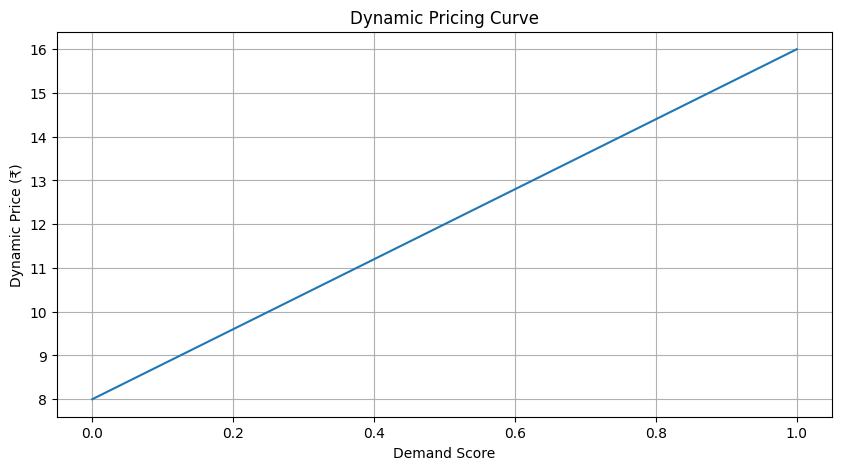

In [130]:
plt.figure(figsize=(10, 5))

plt.plot(
    score_range,
    price_range
)

plt.xlabel("Demand Score")
plt.ylabel("Dynamic Price (₹)")
plt.title("Dynamic Pricing Curve")

plt.grid()

plt.show()

In [131]:
df["DynamicPrice"].value_counts().sort_index()

,count
DynamicPrice,
8.00,229
8.01,3
8.02,4
8.03,6
8.04,10
...,...
13.93,2
13.94,1
13.98,1


In [132]:
print("Minimum price:", df["DynamicPrice"].min())
print("Maximum price:", df["DynamicPrice"].max())
print("Average price:", df["DynamicPrice"].mean())

Minimum price: 8.0
Maximum price: 14.16
Average price: 11.08520552728724


In [133]:
def classify_demand(rate):

    if rate < 0.30:
        return "Low"

    elif rate < 0.60:
        return "Moderate"

    elif rate < 0.80:
        return "High"

    else:
        return "Critical"

In [134]:
df["PredictedDemandLevel"] = (
    df["PredictedOccupancyRate"]
    .apply(classify_demand)
)

In [135]:
df["PredictedDemandLevel"].value_counts()

,count
PredictedDemandLevel,
Moderate,5728
Critical,4972
Low,4962
High,4385


In [136]:
demand_order = [
    "Low",
    "Moderate",
    "High",
    "Critical"
]

df["PredictedDemandLevel"] = pd.Categorical(
    df["PredictedDemandLevel"],
    categories=demand_order,
    ordered=True
)

In [138]:
price_by_demand = (
    df.groupby(
        "PredictedDemandLevel",
        observed=True
    )["DynamicPrice"]
    .mean()
)

price_by_demand

,DynamicPrice
PredictedDemandLevel,
Low,8.945062
Moderate,10.526589
High,11.966778
Critical,13.087510


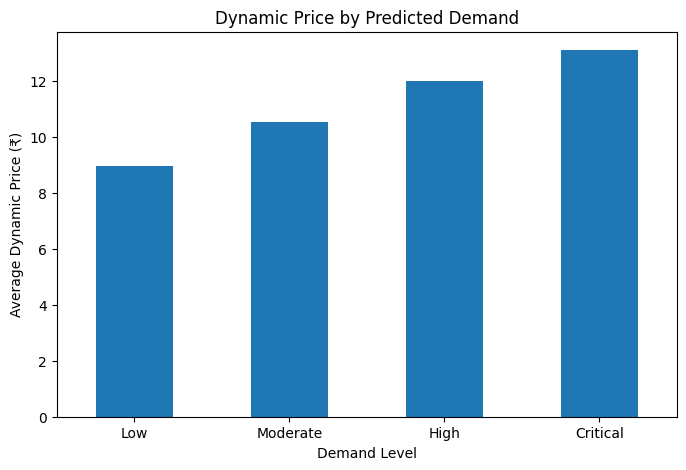

In [139]:
plt.figure(figsize=(8, 5))

price_by_demand.plot(
    kind="bar"
)

plt.xlabel("Demand Level")
plt.ylabel("Average Dynamic Price (₹)")
plt.title("Dynamic Price by Predicted Demand")

plt.xticks(rotation=0)

plt.show()

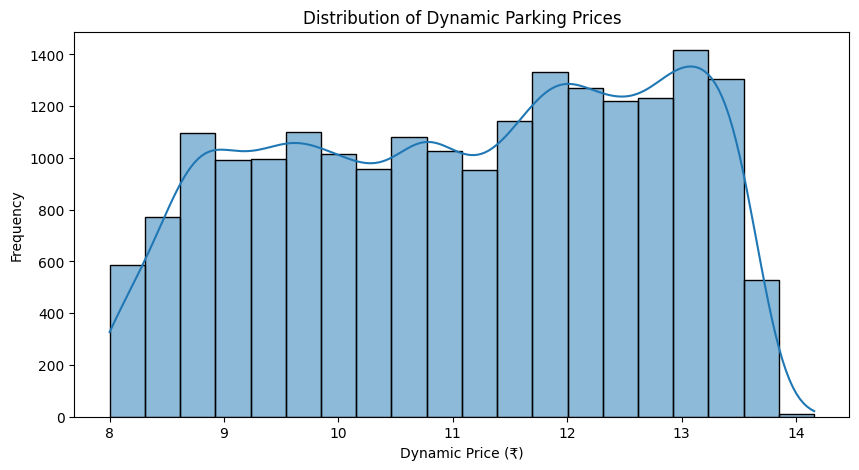

In [140]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["DynamicPrice"].dropna(),
    bins=20,
    kde=True
)

plt.xlabel("Dynamic Price (₹)")
plt.ylabel("Frequency")
plt.title("Distribution of Dynamic Parking Prices")

plt.show()

In [141]:
df["StaticPrice"] = BASE_PRICE

In [142]:
df[
    [
        "StaticPrice",
        "DynamicPrice"
    ]
].head(20)

,StaticPrice,DynamicPrice
0,10,10.37
1,10,10.69
2,10,10.63
3,10,10.70
4,10,10.62
5,10,10.42
6,10,10.14
7,10,9.80
8,10,9.60
9,10,9.51


In [143]:
df["PriceChangeRatio"] = (
    (
        df["DynamicPrice"]
        -
        df["StaticPrice"]
    )
    /
    df["StaticPrice"]
)

In [144]:
df[
    [
        "StaticPrice",
        "DynamicPrice",
        "PriceChangeRatio"
    ]
].head(20)

,StaticPrice,DynamicPrice,PriceChangeRatio
0,10,10.37,0.037
1,10,10.69,0.069
2,10,10.63,0.063
3,10,10.70,0.070
4,10,10.62,0.062
5,10,10.42,0.042
6,10,10.14,0.014
7,10,9.80,-0.020
8,10,9.60,-0.040
9,10,9.51,-0.049


In [145]:
PRICE_ELASTICITY = 0.15

In [146]:
df["SimulatedDynamicOccupancy"] = (
    df["Occupancy"]
    *
    (
        1
        -
        PRICE_ELASTICITY
        *
        df["PriceChangeRatio"]
    )
)

In [147]:
df[
    [
        "Occupancy",
        "DynamicPrice",
        "PriceChangeRatio",
        "SimulatedDynamicOccupancy"
    ]
].head(20)

,Occupancy,DynamicPrice,PriceChangeRatio,SimulatedDynamicOccupancy
0,219,10.37,0.037,217.78455
1,247,10.69,0.069,244.44355
2,259,10.63,0.063,256.55245
3,266,10.70,0.070,263.20700
4,269,10.62,0.062,266.49830
5,263,10.42,0.042,261.34310
6,238,10.14,0.014,237.50020
7,215,9.80,-0.020,215.64500
8,192,9.60,-0.040,193.15200
9,165,9.51,-0.049,166.21275


In [148]:
df["SimulatedDynamicOccupancy"] = (
    df["SimulatedDynamicOccupancy"]
    .clip(lower=0)
)

In [149]:
df["SimulatedDynamicOccupancy"] = np.minimum(
    df["SimulatedDynamicOccupancy"],
    df["Capacity"]
)

In [150]:
print(
    "Minimum simulated occupancy:",
    df["SimulatedDynamicOccupancy"].min()
)

print(
    "Maximum simulated occupancy:",
    df["SimulatedDynamicOccupancy"].max()
)

Minimum simulated occupancy: 0.0
Maximum simulated occupancy: 1194.0


In [151]:
df["StaticOccupancy"] = df["Occupancy"]

In [152]:
# calculate static revenue
df["StaticRevenue"] = (
    df["StaticPrice"]
    *
    df["StaticOccupancy"]
)

In [153]:
# calculate dynamic revenue
df["DynamicRevenue"] = (
    df["DynamicPrice"]
    *
    df["SimulatedDynamicOccupancy"]
)

In [154]:
total_static_revenue = (
    df["StaticRevenue"].sum()
)

total_dynamic_revenue = (
    df["DynamicRevenue"].sum()
)

In [155]:
print(
    "Static Revenue:",
    total_static_revenue
)

print(
    "Dynamic Revenue:",
    total_dynamic_revenue
)

Static Revenue: 71683880
Dynamic Revenue: 81902802.4016635


In [156]:
revenue_improvement = (
    (
        total_dynamic_revenue
        -
        total_static_revenue
    )
    /
    total_static_revenue
) * 100

In [157]:
print(
    f"Simulated revenue improvement: "
    f"{revenue_improvement:.2f}%"
)

Simulated revenue improvement: 14.26%


In [158]:
# average utillization

static_utilization = (
    df["StaticOccupancy"]
    /
    df["Capacity"]
).mean() * 100


dynamic_utilization = (
    df["SimulatedDynamicOccupancy"]
    /
    df["Capacity"]
).mean() * 100

In [159]:
print(
    f"Static utilization: "
    f"{static_utilization:.2f}%"
)

print(
    f"Dynamic utilization: "
    f"{dynamic_utilization:.2f}%"
)

Static utilization: 55.20%
Dynamic utilization: 53.69%


In [161]:
df["StaticCritical"] = (
    df["StaticOccupancy"]
    /
    df["Capacity"]
    >= 0.90
)

df["DynamicCritical"] = (
    df["SimulatedDynamicOccupancy"]
    /
    df["Capacity"]
    >= 0.90
)

In [162]:
static_critical_pct = (
    df["StaticCritical"].mean()
    * 100
)

dynamic_critical_pct = (
    df["DynamicCritical"].mean()
    * 100
)

In [163]:
print(
    f"Static critical periods: "
    f"{static_critical_pct:.2f}%"
)

print(
    f"Dynamic critical periods: "
    f"{dynamic_critical_pct:.2f}%"
)

Static critical periods: 13.54%
Dynamic critical periods: 8.36%


In [164]:
summary = pd.DataFrame({
    "Metric": [
        "Total Revenue",
        "Average Utilization (%)",
        "Critical Periods (%)"
    ],

    "Static Pricing": [
        total_static_revenue,
        static_utilization,
        static_critical_pct
    ],

    "Dynamic Pricing": [
        total_dynamic_revenue,
        dynamic_utilization,
        dynamic_critical_pct
    ]
})

In [165]:
summary

,Metric,Static Pricing,Dynamic Pricing
0,Total Revenue,7.168388e+07,8.190280e+07
1,Average Utilization (%),5.520268e+01,5.369089e+01
2,Critical Periods (%),1.354317e+01,8.360353e+00


In [166]:
# Revenue comparison

revenue_comparison = pd.Series({
    "Static Pricing": total_static_revenue,
    "Dynamic Pricing": total_dynamic_revenue
})

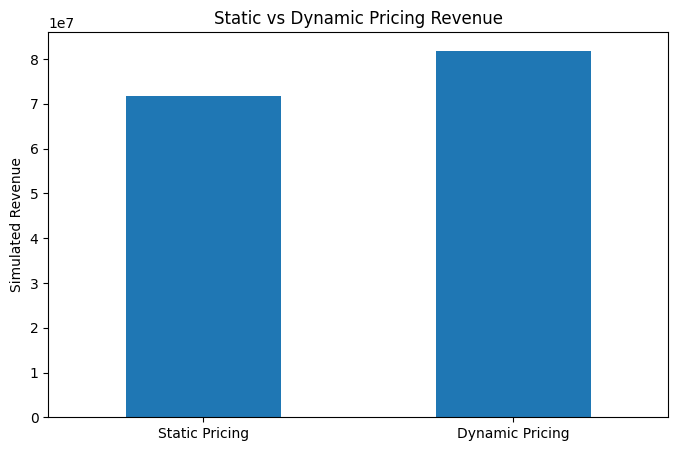

In [167]:
plt.figure(figsize=(8, 5))

revenue_comparison.plot(
    kind="bar"
)

plt.ylabel("Simulated Revenue")
plt.title("Static vs Dynamic Pricing Revenue")

plt.xticks(rotation=0)

plt.show()

In [168]:
# utilization comparison

utilization_comparison = pd.Series({
    "Static Pricing": static_utilization,
    "Dynamic Pricing": dynamic_utilization
})

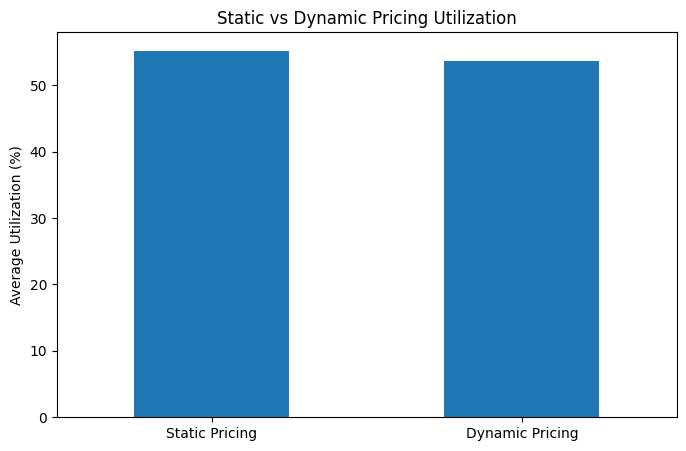

In [169]:
plt.figure(figsize=(8, 5))

utilization_comparison.plot(
    kind="bar"
)

plt.ylabel("Average Utilization (%)")
plt.title("Static vs Dynamic Pricing Utilization")

plt.xticks(rotation=0)

plt.show()

In [170]:
# Critical Period Comparison

critical_comparison = pd.Series({
    "Static Pricing": static_critical_pct,
    "Dynamic Pricing": dynamic_critical_pct
})


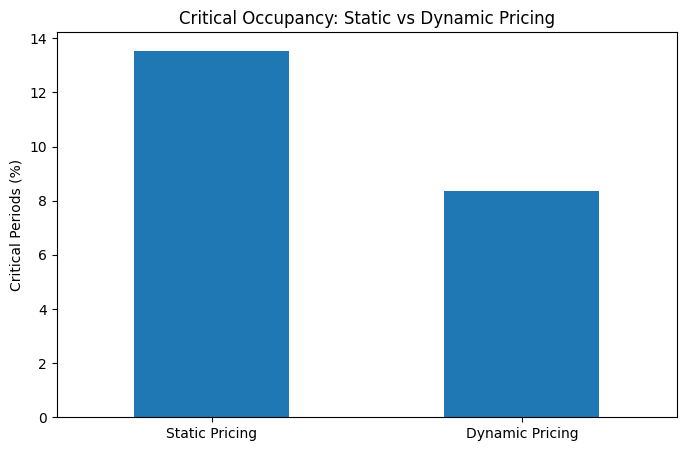

In [171]:
plt.figure(figsize=(8, 5))

critical_comparison.plot(
    kind="bar"
)

plt.ylabel("Critical Periods (%)")
plt.title("Critical Occupancy: Static vs Dynamic Pricing")

plt.xticks(rotation=0)

plt.show()

In [173]:
# Sensitivity Analysis

PRICE_ELASTICITY = 0.15

elasticities = [
    0.05,
    0.10,
    0.15,
    0.20,
    0.25,
    0.30
]
sensitivity_results = []

In [174]:
for elasticity in elasticities:

    simulated_occupancy = (
        df["Occupancy"]
        *
        (
            1
            -
            elasticity
            *
            df["PriceChangeRatio"]
        )
    )

    simulated_occupancy = (
        simulated_occupancy
        .clip(lower=0)
    )

    simulated_occupancy = np.minimum(
        simulated_occupancy,
        df["Capacity"]
    )

    simulated_revenue = (
        df["DynamicPrice"]
        *
        simulated_occupancy
    ).sum()

    revenue_improvement = (
        (
            simulated_revenue
            -
            total_static_revenue
        )
        /
        total_static_revenue
    ) * 100

    utilization = (
        simulated_occupancy
        /
        df["Capacity"]
    ).mean() * 100

    critical_periods = (
        (
            simulated_occupancy
            /
            df["Capacity"]
        ) >= 0.90
    ).mean() * 100

    sensitivity_results.append({
        "Price Elasticity": elasticity,
        "Dynamic Revenue": simulated_revenue,
        "Revenue Improvement (%)": revenue_improvement,
        "Utilization (%)": utilization,
        "Critical Periods (%)": critical_periods
    })

In [175]:
sensitivity_df = pd.DataFrame(
    sensitivity_results
)

In [176]:
sensitivity_df

,Price Elasticity,Dynamic Revenue,Revenue Improvement (%),Utilization (%),Critical Periods (%)
0,0.05,8.354318e+07,16.543882,54.697465,11.747394
1,0.10,8.272310e+07,15.399862,54.194244,10.061356
2,0.15,8.190280e+07,14.255538,53.690894,8.360353
3,0.20,8.108241e+07,13.111077,53.187486,6.559585
4,0.25,8.026197e+07,11.966554,52.684044,4.589215
5,0.30,7.944140e+07,10.821851,52.180529,0.628523


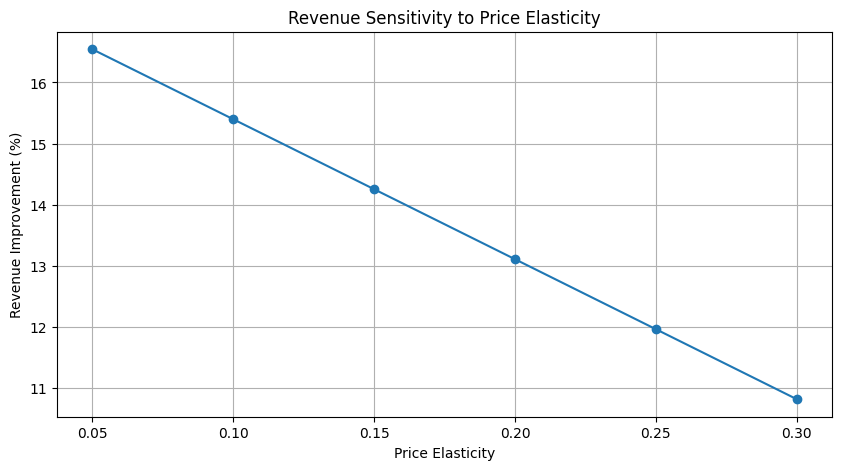

In [177]:
plt.figure(figsize=(10, 5))

plt.plot(
    sensitivity_df["Price Elasticity"],
    sensitivity_df["Revenue Improvement (%)"],
    marker="o"
)

plt.xlabel("Price Elasticity")
plt.ylabel("Revenue Improvement (%)")
plt.title("Revenue Sensitivity to Price Elasticity")

plt.grid()

plt.show()

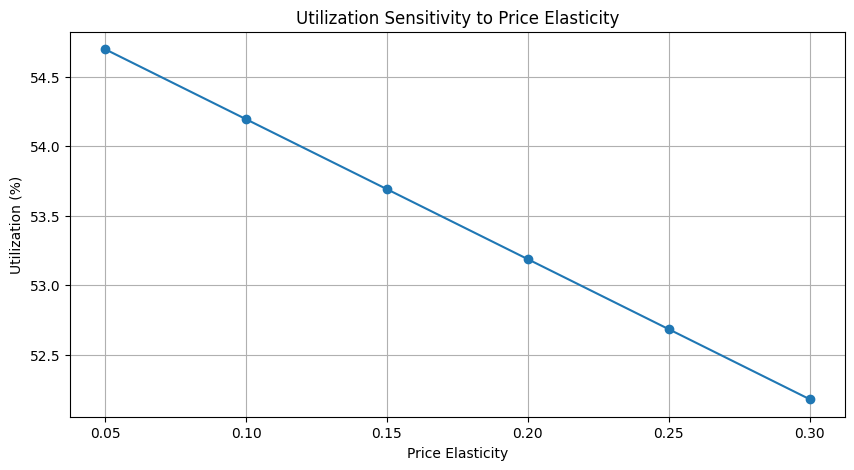

In [178]:
plt.figure(figsize=(10, 5))

plt.plot(
    sensitivity_df["Price Elasticity"],
    sensitivity_df["Utilization (%)"],
    marker="o"
)

plt.xlabel("Price Elasticity")
plt.ylabel("Utilization (%)")
plt.title("Utilization Sensitivity to Price Elasticity")

plt.grid()

plt.show()

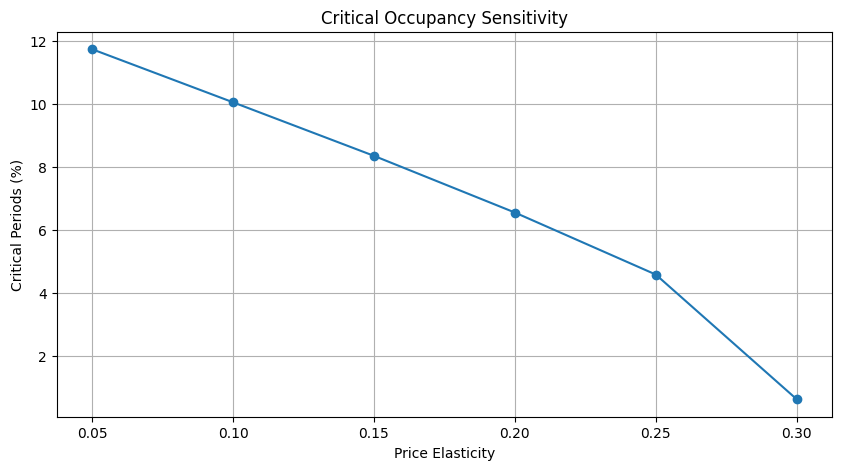

In [179]:
plt.figure(figsize=(10, 5))

plt.plot(
    sensitivity_df["Price Elasticity"],
    sensitivity_df["Critical Periods (%)"],
    marker="o"
)

plt.xlabel("Price Elasticity")
plt.ylabel("Critical Periods (%)")
plt.title("Critical Occupancy Sensitivity")

plt.grid()

plt.show()

In [180]:
import os

os.makedirs(
    "/processed",
    exist_ok=True
)

In [181]:
pricing_columns = [
    "SystemCodeNumber",
    "LastUpdated",
    "Capacity",
    "Occupancy",
    "PredictedOccupancy",
    "PredictedOccupancyRate",
    "PredictedOccupancyPercent",
    "PredictedChange",
    "DemandMomentum",
    "DemandScore",
    "PredictedDemandLevel",
    "StaticPrice",
    "DynamicPrice",
    "PriceChangeRatio",
    "StaticOccupancy",
    "SimulatedDynamicOccupancy",
    "StaticRevenue",
    "DynamicRevenue"
]

In [182]:
pricing_df = df[pricing_columns].copy()

In [183]:
pricing_df.to_csv(
    "dynamic_pricing_results.csv",
    index=False
)

In [6]:
X = df[features]

In [7]:
df["PredictedOccupancy"] = model.predict(X)

In [8]:
df[
    [
        "SystemCodeNumber",
        "LastUpdated",
        "Occupancy",
        "PredictedOccupancy",
        "Capacity"
    ]
].head(20)

,SystemCodeNumber,LastUpdated,Occupancy,PredictedOccupancy,Capacity
0,BHMBCCMKT01,2016-10-04 10:59:48,219,236.604965,577
1,BHMBCCMKT01,2016-10-04 11:25:47,247,268.383423,577
2,BHMBCCMKT01,2016-10-04 11:59:44,259,267.439972,577
3,BHMBCCMKT01,2016-10-04 12:29:45,266,274.371979,577
4,BHMBCCMKT01,2016-10-04 13:02:48,269,269.842468,577
5,BHMBCCMKT01,2016-10-04 13:29:45,263,253.360764,577
6,BHMBCCMKT01,2016-10-04 14:02:47,238,225.781311,577
7,BHMBCCMKT01,2016-10-04 14:29:49,215,194.083923,577
8,BHMBCCMKT01,2016-10-04 14:57:13,192,172.802429,577
9,BHMBCCMKT01,2016-10-04 15:30:14,165,158.305008,577


In [9]:
df["PredictedOccupancy"] = (
    df["PredictedOccupancy"]
    .clip(
        lower=0,
        upper=df["Capacity"]
    )
)

In [10]:
print(
    df["PredictedOccupancy"].min()
)

print(
    df["PredictedOccupancy"].max()
)

0.0
1194.0


In [11]:
df["PredictedOccupancyRate"] = (
    df["PredictedOccupancy"]
    / df["Capacity"]
)

In [12]:
df["PredictedOccupancyPercent"] = (
    df["PredictedOccupancyRate"] * 100
)

In [13]:
df[
    [
        "Capacity",
        "PredictedOccupancy",
        "PredictedOccupancyPercent"
    ]
].head()

,Capacity,PredictedOccupancy,PredictedOccupancyPercent
0,577,236.604965,41.006060
1,577,268.383423,46.513591
2,577,267.439972,46.350082
3,577,274.371979,47.551469
4,577,269.842468,46.766459


In [14]:
def classify_demand(rate):

    if rate < 0.30:
        return "Low"

    elif rate < 0.60:
        return "Moderate"

    elif rate < 0.80:
        return "High"

    else:
        return "Critical"

In [15]:
df["PredictedDemandLevel"] = (
    df["PredictedOccupancyRate"]
    .apply(classify_demand)
)

In [16]:
df["PredictedDemandLevel"].value_counts()

,count
PredictedDemandLevel,
Moderate,5728
Critical,4972
Low,4962
High,4385


Build a demand multiplier

In [18]:
def pricing_multiplier(rate):

    if rate < 0.30:
        return 0.80

    elif rate < 0.60:
        return 1.00

    elif rate < 0.80:
        return 1.20

    elif rate < 0.90:
        return 1.40

    else:
        return 1.60

In [19]:
df["PriceMultiplier"] = (
    df["PredictedOccupancyRate"]
    .apply(pricing_multiplier)
)

In [20]:
BASE_PRICE = 10

df["DynamicPrice"] = (
    BASE_PRICE
    * df["PriceMultiplier"]
)

In [21]:
df[
    [
        "SystemCodeNumber",
        "PredictedOccupancyPercent",
        "PredictedDemandLevel",
        "PriceMultiplier",
        "DynamicPrice"
    ]
].head(20)

,SystemCodeNumber,PredictedOccupancyPercent,PredictedDemandLevel,PriceMultiplier,DynamicPrice
0,BHMBCCMKT01,41.006060,Moderate,1.0,10.0
1,BHMBCCMKT01,46.513591,Moderate,1.0,10.0
2,BHMBCCMKT01,46.350082,Moderate,1.0,10.0
3,BHMBCCMKT01,47.551469,Moderate,1.0,10.0
4,BHMBCCMKT01,46.766459,Moderate,1.0,10.0
5,BHMBCCMKT01,43.910011,Moderate,1.0,10.0
6,BHMBCCMKT01,39.130210,Moderate,1.0,10.0
7,BHMBCCMKT01,33.636728,Moderate,1.0,10.0
8,BHMBCCMKT01,29.948428,Low,0.8,8.0
9,BHMBCCMKT01,27.435877,Low,0.8,8.0


In [22]:
df["PredictedChange"] = (
    df["PredictedOccupancy"]
    - df["Occupancy"]
)

In [23]:
df[
    [
        "Occupancy",
        "PredictedOccupancy",
        "PredictedChange"
    ]
].head()

,Occupancy,PredictedOccupancy,PredictedChange
0,219,236.604965,17.604965
1,247,268.383423,21.383423
2,259,267.439972,8.439972
3,266,274.371979,8.371979
4,269,269.842468,0.842468


In [24]:
df["DemandScore"] = (
    0.7 * df["PredictedOccupancyRate"]
    +
    0.3 * (
        df["PredictedChange"]
        / df["Capacity"]
    )
)

In [25]:
df["DemandScore"] = df["DemandScore"].clip(
    0,
    1
)

In [26]:
df["DemandScore"].describe()

,DemandScore
count,20047.000000
mean,0.385660
std,0.201259
min,0.000000
25%,0.211117
50%,0.399925
75%,0.562023
max,0.770055


In [27]:
df["DynamicPrice"] = (
    BASE_PRICE
    *
    (
        0.8
        +
        0.8 * df["DemandScore"]
    )
)

In [28]:
MIN_PRICE = 8
MAX_PRICE = 16

In [29]:
df["DynamicPrice"] = (
    df["DynamicPrice"]
    .clip(
        MIN_PRICE,
        MAX_PRICE
    )
)

In [30]:
df["DynamicPrice"] = (
    df["DynamicPrice"]
    .round(2)
)

Build the Dynamic Pricing Engine

In [31]:
BASE_PRICE = 10
MIN_PRICE = 8
MAX_PRICE = 16

In [32]:
df["PredictedOccupancyRate"] = (
    df["PredictedOccupancy"] / df["Capacity"]
)

In [33]:
df["PredictedOccupancyPercent"] = (
    df["PredictedOccupancyRate"] * 100
)

In [34]:
df[
    [
        "Occupancy",
        "Capacity",
        "PredictedOccupancy",
        "PredictedOccupancyPercent"
    ]
].head(10)

,Occupancy,Capacity,PredictedOccupancy,PredictedOccupancyPercent
0,219,577,236.604965,41.006060
1,247,577,268.383423,46.513591
2,259,577,267.439972,46.350082
3,266,577,274.371979,47.551469
4,269,577,269.842468,46.766459
5,263,577,253.360764,43.910011
6,238,577,225.781311,39.130210
7,215,577,194.083923,33.636728
8,192,577,172.802429,29.948428
9,165,577,158.305008,27.435877


In [35]:
df["PredictedChange"] = (
    df["PredictedOccupancy"]
    - df["Occupancy"]
)

In [36]:
df["DemandMomentum"] = (
    df["PredictedChange"] / df["Capacity"]
)

In [37]:
df["DemandMomentum"].describe()

,DemandMomentum
count,20047.000000
mean,-0.001300
std,0.095973
min,-0.936250
25%,-0.017928
50%,0.008851
75%,0.035574
max,0.416613


In [38]:
df["DemandScore"] = (
    0.7 * df["PredictedOccupancyRate"]
    +
    0.3 * df["DemandMomentum"]
)

In [39]:
df["DemandScore"] = (
    df["DemandScore"]
    .clip(0, 1)
)

In [40]:
df["DynamicPrice"] = (
    BASE_PRICE
    *
    (
        0.8
        +
        0.8 * df["DemandScore"]
    )
)

In [42]:
df.head()

,SystemCodeNumber,Capacity,Occupancy,LastUpdated,OccupancyRate,OccupancyPercent,AvailableSpaces,Date,Hour,Minute,...,TimeDiff,PredictedOccupancy,PredictedOccupancyRate,PredictedOccupancyPercent,PredictedDemandLevel,PriceMultiplier,DynamicPrice,PredictedChange,DemandScore,DemandMomentum
0,BHMBCCMKT01,577,219,2016-10-04 10:59:48,0.379549,37.954939,358,2016-10-04,10,59,...,0 days 00:32:59,236.604965,0.410061,41.006060,Moderate,1.0,10.369566,17.604965,0.296196,0.030511
1,BHMBCCMKT01,577,247,2016-10-04 11:25:47,0.428076,42.807626,330,2016-10-04,11,25,...,0 days 00:25:59,268.383423,0.465136,46.513591,Moderate,1.0,10.693704,21.383423,0.336713,0.037060
2,BHMBCCMKT01,577,259,2016-10-04 11:59:44,0.448873,44.887348,318,2016-10-04,11,59,...,0 days 00:33:57,267.439972,0.463501,46.350082,Moderate,1.0,10.630710,8.439972,0.328839,0.014627
3,BHMBCCMKT01,577,266,2016-10-04 12:29:45,0.461005,46.100520,311,2016-10-04,12,29,...,0 days 00:30:01,274.371979,0.475515,47.551469,Moderate,1.0,10.697705,8.371979,0.337213,0.014509
4,BHMBCCMKT01,577,269,2016-10-04 13:02:48,0.466205,46.620451,308,2016-10-04,13,2,...,0 days 00:33:03,269.842468,0.467665,46.766459,Moderate,1.0,10.622426,0.842468,0.327803,0.001460


In [44]:
df["DynamicPrice"] = (
    df["DynamicPrice"]
    .clip(MIN_PRICE, MAX_PRICE)
    .round(2)
)

In [45]:
df[
    [
        "Occupancy",
        "PredictedOccupancy",
        "DemandScore",
        "DynamicPrice"
    ]
].head(20)

,Occupancy,PredictedOccupancy,DemandScore,DynamicPrice
0,219,236.604965,0.296196,10.37
1,247,268.383423,0.336713,10.69
2,259,267.439972,0.328839,10.63
3,266,274.371979,0.337213,10.70
4,269,269.842468,0.327803,10.62
5,263,253.360764,0.302358,10.42
6,238,225.781311,0.267559,10.14
7,215,194.083923,0.224582,9.80
8,192,172.802429,0.199658,9.60
9,165,158.305008,0.188570,9.51


In [48]:
df["DynamicPrice"] = (
    df["DynamicPrice"]
    .clip(
        MIN_PRICE,
        MAX_PRICE
    )
)

In [49]:
df["DynamicPrice"] = (
    df["DynamicPrice"]
    .round(2)
)

In [50]:
df["StaticPrice"] = BASE_PRICE

In [51]:
score_range = np.linspace(0, 1, 100)

price_range = (
    BASE_PRICE *
    (
        0.8 +
        0.8 * score_range
    )
)

price_range = np.clip(
    price_range,
    MIN_PRICE,
    MAX_PRICE
)

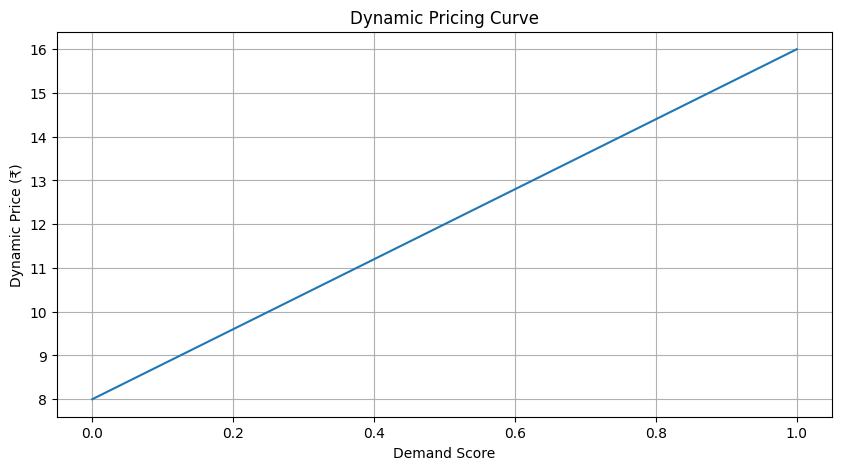

In [52]:
plt.figure(figsize=(10, 5))

plt.plot(
    score_range,
    price_range
)

plt.xlabel("Demand Score")
plt.ylabel("Dynamic Price (₹)")
plt.title("Dynamic Pricing Curve")

plt.grid()

plt.show()

In [53]:
df["DynamicPrice"].describe()

,DynamicPrice
count,20047.000000
mean,11.085335
std,1.610076
min,8.000000
25%,9.690000
50%,11.200000
75%,12.500000
max,14.160000


In [54]:
df[
    [
        "PredictedOccupancyPercent",
        "DemandMomentum",
        "DemandScore",
        "StaticPrice",
        "DynamicPrice"
    ]
].head(20)

,PredictedOccupancyPercent,DemandMomentum,DemandScore,StaticPrice,DynamicPrice
0,41.006060,0.030511,0.296196,10,10.37
1,46.513591,0.037060,0.336713,10,10.69
2,46.350082,0.014627,0.328839,10,10.63
3,47.551469,0.014509,0.337213,10,10.70
4,46.766459,0.001460,0.327803,10,10.62
5,43.910011,-0.016706,0.302358,10,10.42
6,39.130210,-0.021176,0.267559,10,10.14
7,33.636728,-0.036250,0.224582,10,9.80
8,29.948428,-0.033271,0.199658,10,9.60
9,27.435877,-0.011603,0.188570,10,9.51


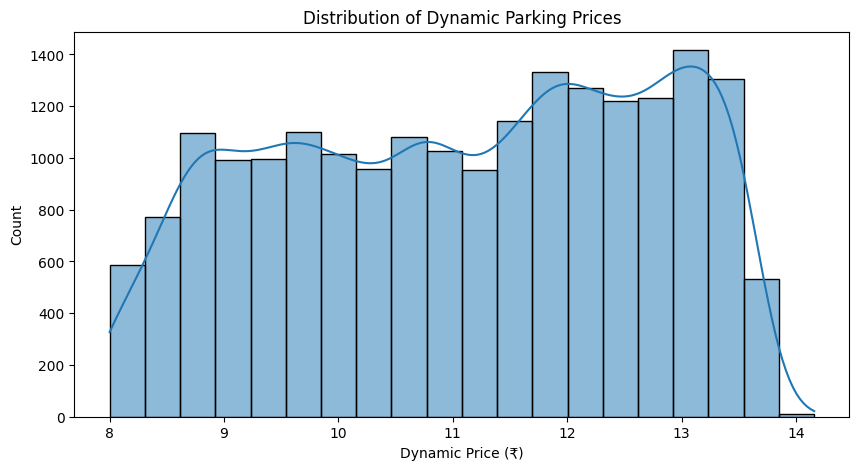

In [55]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["DynamicPrice"],
    bins=20,
    kde=True
)

plt.xlabel("Dynamic Price (₹)")
plt.title("Distribution of Dynamic Parking Prices")

plt.show()

In [56]:
def classify_demand(rate):

    if rate < 0.30:
        return "Low"

    elif rate < 0.60:
        return "Moderate"

    elif rate < 0.80:
        return "High"

    else:
        return "Critical"

In [57]:
df["PredictedDemandLevel"] = (
    df["PredictedOccupancyRate"]
    .apply(classify_demand)
)

In [59]:
price_by_demand = (
    df.groupby("PredictedDemandLevel")["DynamicPrice"]
      .mean()
)

price_by_demand

,DynamicPrice
PredictedDemandLevel,
Critical,13.087629
High,11.966778
Low,8.945062
Moderate,10.526589


In [60]:
demand_order = [
    "Low",
    "Moderate",
    "High",
    "Critical"
]

df["PredictedDemandLevel"] = pd.Categorical(
    df["PredictedDemandLevel"],
    categories=demand_order,
    ordered=True
)

In [61]:
price_by_demand = (
    df.groupby(
        "PredictedDemandLevel",
        observed=True
    )["DynamicPrice"]
    .mean()
)

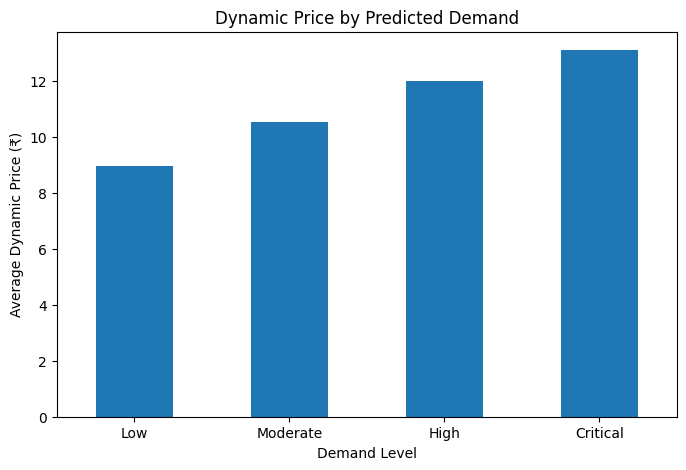

In [62]:
plt.figure(figsize=(8, 5))

price_by_demand.plot(
    kind="bar"
)

plt.xlabel("Demand Level")
plt.ylabel("Average Dynamic Price (₹)")
plt.title("Dynamic Price by Predicted Demand")

plt.xticks(rotation=0)

plt.show()

Estimate Demand Response to Price

In [63]:
df["PriceChangeRatio"] = (
    (df["DynamicPrice"] - df["StaticPrice"])
    / df["StaticPrice"]
)

In [65]:
PRICE_ELASTICITY = 0.15

In [66]:
df["SimulatedDynamicOccupancy"] = (
    df["Occupancy"]
    *
    (
        1
        -
        PRICE_ELASTICITY
        *
        df["PriceChangeRatio"]
    )
)

In [67]:
df["SimulatedDynamicOccupancy"] = (
    df["SimulatedDynamicOccupancy"]
    .clip(
        lower=0
    )
)

In [68]:
df["SimulatedDynamicOccupancy"] = np.minimum(
    df["SimulatedDynamicOccupancy"],
    df["Capacity"]
)

In [69]:
df["StaticOccupancy"] = df["Occupancy"]

In [70]:
df["StaticRevenue"] = (
    df["StaticPrice"]
    *
    df["StaticOccupancy"]
)

In [71]:
df["DynamicRevenue"] = (
    df["DynamicPrice"]
    *
    df["SimulatedDynamicOccupancy"]
)

In [72]:
total_static_revenue = (
    df["StaticRevenue"].sum()
)

total_dynamic_revenue = (
    df["DynamicRevenue"].sum()
)

In [73]:
print(
    "Static Revenue:",
    total_static_revenue
)

print(
    "Dynamic Revenue:",
    total_dynamic_revenue
)

Static Revenue: 71683880
Dynamic Revenue: 81911410.3610875


In [74]:
revenue_improvement = (
    (
        total_dynamic_revenue
        -
        total_static_revenue
    )
    /
    total_static_revenue
) * 100

In [75]:
print(
    f"Revenue improvement: "
    f"{revenue_improvement:.2f}%"
)

Revenue improvement: 14.27%


In [76]:
static_utilization = (
    df["StaticOccupancy"]
    / df["Capacity"]
).mean() * 100

In [77]:
dynamic_utilization = (
    df["SimulatedDynamicOccupancy"]
    / df["Capacity"]
).mean() * 100

In [78]:
print(
    f"Static utilization: "
    f"{static_utilization:.2f}%"
)

print(
    f"Dynamic utilization: "
    f"{dynamic_utilization:.2f}%"
)

Static utilization: 55.20%
Dynamic utilization: 53.69%


In [79]:
df["StaticCritical"] = (
    df["StaticOccupancy"]
    / df["Capacity"]
    >= 0.90
)

In [80]:
df["DynamicCritical"] = (
    df["SimulatedDynamicOccupancy"]
    / df["Capacity"]
    >= 0.90
)

In [81]:
static_critical_pct = (
    df["StaticCritical"].mean()
    * 100
)

dynamic_critical_pct = (
    df["DynamicCritical"].mean()
    * 100
)

In [82]:
print(
    f"Static critical periods: "
    f"{static_critical_pct:.2f}%"
)

print(
    f"Dynamic critical periods: "
    f"{dynamic_critical_pct:.2f}%"
)

Static critical periods: 13.54%
Dynamic critical periods: 8.37%


In [83]:
summary = pd.DataFrame({
    "Metric": [
        "Total Revenue",
        "Average Utilization (%)",
        "Critical Periods (%)"
    ],

    "Static Pricing": [
        total_static_revenue,
        static_utilization,
        static_critical_pct
    ],

    "Dynamic Pricing": [
        total_dynamic_revenue,
        dynamic_utilization,
        dynamic_critical_pct
    ]
})

In [84]:
summary

,Metric,Static Pricing,Dynamic Pricing
0,Total Revenue,7.168388e+07,8.191141e+07
1,Average Utilization (%),5.520268e+01,5.369276e+01
2,Critical Periods (%),1.354317e+01,8.365341e+00


In [85]:
score_range = np.linspace(0, 1, 100)

In [86]:
price_range = (
    BASE_PRICE *
    (
        0.8 + 0.8 * score_range
    )
)

In [87]:
price_range = np.clip(
    price_range,
    MIN_PRICE,
    MAX_PRICE
)

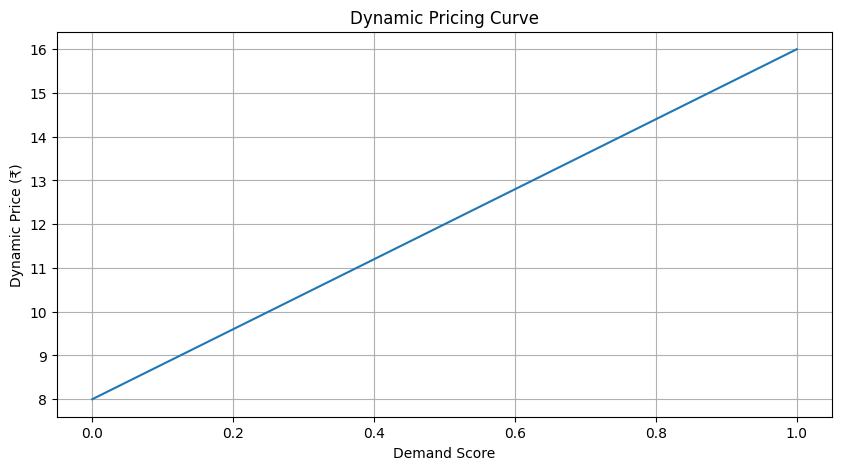

In [88]:
plt.figure(figsize=(10, 5))

plt.plot(
    score_range,
    price_range
)

plt.xlabel("Demand Score")
plt.ylabel("Dynamic Price (₹)")
plt.title("Dynamic Pricing Curve")

plt.grid()

plt.show()

In [90]:
df["DynamicPrice"].describe()

,DynamicPrice
count,20047.000000
mean,11.085335
std,1.610076
min,8.000000
25%,9.690000
50%,11.200000
75%,12.500000
max,14.160000


In [91]:
df["DynamicPrice"].value_counts().sort_index()

,count
DynamicPrice,
8.00,229
8.01,3
8.02,4
8.03,6
8.04,10
...,...
13.93,2
13.94,1
13.98,1


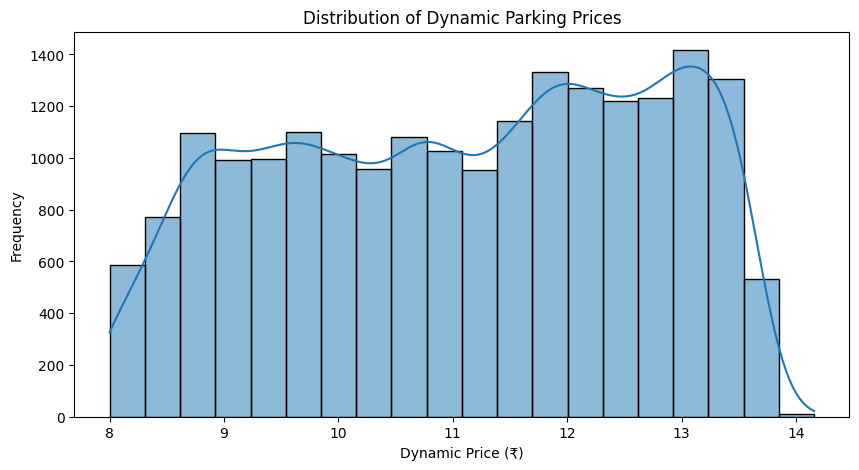

In [92]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["DynamicPrice"],
    bins=20,
    kde=True
)

plt.xlabel("Dynamic Price (₹)")
plt.ylabel("Frequency")
plt.title("Distribution of Dynamic Parking Prices")

plt.show()

In [93]:
def classify_demand(rate):

    if rate < 0.30:
        return "Low"

    elif rate < 0.60:
        return "Moderate"

    elif rate < 0.80:
        return "High"

    else:
        return "Critical"

In [94]:
df["PredictedDemandLevel"] = (
    df["PredictedOccupancyRate"]
    .apply(classify_demand)
)

In [95]:
df["PredictedDemandLevel"].value_counts()

,count
PredictedDemandLevel,
Moderate,5728
Critical,4972
Low,4962
High,4385


In [96]:
demand_order = [
    "Low",
    "Moderate",
    "High",
    "Critical"
]

df["PredictedDemandLevel"] = pd.Categorical(
    df["PredictedDemandLevel"],
    categories=demand_order,
    ordered=True
)

In [97]:
df["PredictedDemandLevel"].value_counts().sort_index()

,count
PredictedDemandLevel,
Low,4962
Moderate,5728
High,4385
Critical,4972


In [98]:
price_by_demand = (
    df.groupby(
        "PredictedDemandLevel",
        observed=True
    )["DynamicPrice"]
    .mean()
)

In [99]:
price_by_demand

,DynamicPrice
PredictedDemandLevel,
Low,8.945062
Moderate,10.526589
High,11.966778
Critical,13.087629


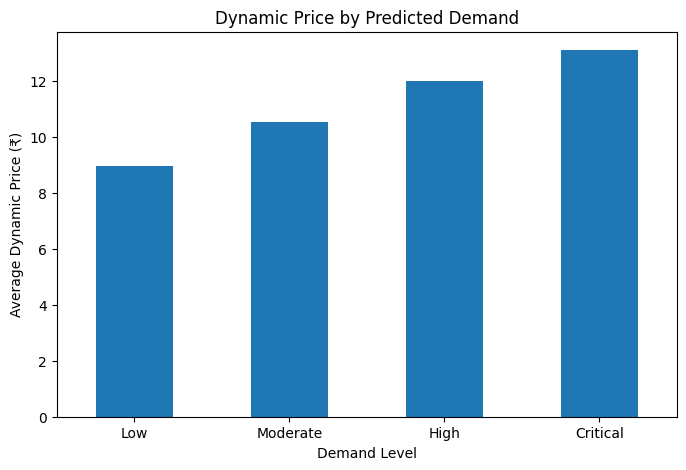

In [100]:
plt.figure(figsize=(8, 5))

price_by_demand.plot(
    kind="bar"
)

plt.xlabel("Demand Level")
plt.ylabel("Average Dynamic Price (₹)")
plt.title("Dynamic Price by Predicted Demand")

plt.xticks(rotation=0)

plt.show()

In [101]:
BASE_PRICE = 10

df["StaticPrice"] = BASE_PRICE

In [102]:
df[
    [
        "StaticPrice",
        "DynamicPrice"
    ]
].head(20)


,StaticPrice,DynamicPrice
0,10,10.37
1,10,10.69
2,10,10.63
3,10,10.70
4,10,10.62
5,10,10.42
6,10,10.14
7,10,9.80
8,10,9.60
9,10,9.51


In [103]:
df["PriceChangeRatio"] = (
    (df["DynamicPrice"] - df["StaticPrice"])
    / df["StaticPrice"]
)

In [104]:
df[
    [
        "StaticPrice",
        "DynamicPrice",
        "PriceChangeRatio"
    ]
].head(20)

,StaticPrice,DynamicPrice,PriceChangeRatio
0,10,10.37,0.037
1,10,10.69,0.069
2,10,10.63,0.063
3,10,10.70,0.070
4,10,10.62,0.062
5,10,10.42,0.042
6,10,10.14,0.014
7,10,9.80,-0.020
8,10,9.60,-0.040
9,10,9.51,-0.049


In [105]:
print(
    "Minimum price:",
    df["DynamicPrice"].min()
)

print(
    "Maximum price:",
    df["DynamicPrice"].max()
)

print(
    "Average price:",
    df["DynamicPrice"].mean()
)

Minimum price: 8.0
Maximum price: 14.16
Average price: 11.085334962837331


In [106]:
PRICE_ELASTICITY = 0.15

In [107]:
df["SimulatedDynamicOccupancy"] = (
    df["Occupancy"]
    *
    (
        1
        -
        PRICE_ELASTICITY
        *
        df["PriceChangeRatio"]
    )
)